In [16]:
import os
import numpy as np
import pandas as pd
from scipy.io import loadmat

# ------------------------------------------------------------
# Load .mat file
# ------------------------------------------------------------
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/ICA_Results/Depression_ICA_Analyses_Clinical_Outcomes')
data = loadmat('Clinical_Outcomes_Workspace.mat', squeeze_me=True, struct_as_record=False)

# ------------------------------------------------------------
# Load variables
# ------------------------------------------------------------
depind = np.squeeze(data['depind']).astype(int)   # MATLAB indices (1-based)
hcind = np.squeeze(data['hcind']).astype(int)

a = np.squeeze(data['a'])                         # ICA loadings matrix (2819 × 68)

# Convert MATLAB 1-based indexing → Python 0-based
depind = depind - 1

# Subset loadings for depressed subjects only
dep_loadings = a[depind, :]                       # shape: (2743 × 68)

# Behavioral variables (already depression-only in your .mat file)
age = data['age'].ravel()
Location_ID = data['Location_ID'].ravel()
sex_coded = data['sex_coded'].ravel()
worry_rumination = data['Worry_Rumination'].ravel()
moodiness = data['Moodiness'].ravel()
social_disinterest = data['Social_Disinterest'].ravel()

print("Depressed loadings shape:", dep_loadings.shape)
print("Behavioral variable length:", len(age))

# ------------------------------------------------------------
# Build DataFrame
# ------------------------------------------------------------
df = pd.DataFrame({
    "age": age,
    "Location_ID": Location_ID,
    "sex_coded": sex_coded,
    "worry_rumination": worry_rumination,
    "moodiness": moodiness,
    "social_disinterest": social_disinterest
})

# ------------------------------------------------------------
# Add loading parameters (68 components)
# ------------------------------------------------------------
nComp = dep_loadings.shape[1]

for i in range(nComp):
    df[f"loading_{i+1}"] = dep_loadings[:, i]

print(df.head())
print("Final DataFrame shape:", df.shape)


Depressed loadings shape: (2743, 68)
Behavioral variable length: 2743
   age  Location_ID  sex_coded  worry_rumination  moodiness  \
0   38           11          2          1.225029   0.467743   
1   21           10          1          0.323497   0.678197   
2   33            2          1          0.717705   1.217534   
3   54           10          2         -0.951024   0.677486   
4   36           13          1          1.591287   0.507338   

   social_disinterest  loading_1  loading_2  loading_3  loading_4  ...  \
0           -0.292800   0.917116   1.128232   0.618952   0.645581  ...   
1            1.353072  -0.196811   1.121986   1.301531   1.275548  ...   
2            0.620188   1.394336   0.644633   0.514857   0.177735  ...   
3            0.404452  -1.175541  -2.030377  -1.528015  -2.448613  ...   
4            0.671212   0.850474   1.175935   0.591984   0.939523  ...   

   loading_59  loading_60  loading_61  loading_62  loading_63  loading_64  \
0   -1.040568    0.297904    

In [11]:
#go to working directory and load data frame aka the .csv file
#load factor scores from this
os.chdir('/Users/amrithah/Desktop/CalhounLab/Dissertation/Projects/Chapter7_Paper_6_Diss_Clinical_Outcomes/clinical outcomes measures')
df = pd.read_csv("depression_cov_dx_symp_rest_conc_matched_qc_totalbrain(in)_factors.csv")
print(df.columns.tolist()) #print headers of each variable so I can load correctly

['CID', 'Location_ID', 'age', 'sex_coded', 'dx', 'conc_filename', 'rest_filename', 'Hallucinogen_related_disorders', 'Borderline', 'Eating_Disorder_unspecified', 'Passive_Aggressive_Personality_Disorder', 'Mood_Disorder_NOS', 'Amnestic_disorders', 'Opioid_Related_Disorder', 'SubstanceAbuseDisorder', 'Factitious_disorder', 'Elimination_Disorder', 'Aspergers', 'Cannabis_Related_Disorder', 'Toxicicity_Encephalopathy', 'frontotemporal_dementia', 'Depression_NOS', 'Dissociative_Disorder', 'Cocaine_Related_Disorder', 'Vascular_dementia', 'Somatoform_disorders', 'Depressive_Disorder', 'Personallity_Cluster_A', 'Amphetamine_Related_Disorder', 'Disruptive_Behavior', 'TemporalDysfunction', 'Mathematics_disorder', 'Bipolar_Disorder', 'Antisocial_Personality_Disorder', 'Caffeine_related_disorders', 'Schizoid_Personality_Disorder', 'Learning_Disorder', 'Personality_Disorder_NOS', 'dysgraphia', 'Nicotine_related_disorders', 'Polysubstance_related_disorder', 'BrainTrauma', 'Substance_dependence', 'Bu

In [17]:
import pandas as pd

# Ensure each variable is 1‑D
worry_rumination = worry_rumination.squeeze()
moodiness = moodiness.squeeze()
social_disinterest = social_disinterest.squeeze()

print(worry_rumination.shape)
print(moodiness.shape)
print(social_disinterest.shape)

# Build DataFrame
df = pd.DataFrame({
    'Worry_Rumination': worry_rumination,
    'Moodiness': moodiness,
    'Social_Disinterest': social_disinterest
})

# Correlation matrix
correlation_matrix = df.corr()
correlation_matrix


(2743,)
(2743,)
(2743,)


,Worry_Rumination,Moodiness,Social_Disinterest
Worry_Rumination,1.000000,-0.019811,-0.058648
Moodiness,-0.019811,1.000000,-0.011493
Social_Disinterest,-0.058648,-0.011493,1.000000


In [19]:
# ------------------------------------------------------------
# Add loading parameters (use dep_loadings, NOT depind)
# ------------------------------------------------------------
for i in range(68):
    df[f"loading_{i+1}"] = dep_loadings[:, i]

# Storage lists
p_worry = []
T_worry = []
p_mood = []
T_mood = []
p_social = []
T_social = []

# ------------------------------------------------------------
# Run regressions for each loading
# ------------------------------------------------------------
for i in range(68):
    loading = f"loading_{i+1}"

    formula = (
        f"{loading} ~ age + C(sex_coded) + C(Location_ID) + "
        f"worry_rumination + moodiness + social_disinterest"
    )

    model = ols(formula, data=df).fit()
    anova = sm.stats.anova_lm(model, typ=2)

    # Extract p-values
    p_worry.append(float(anova.loc["worry_rumination", "PR(>F)"]))
    p_mood.append(float(anova.loc["moodiness", "PR(>F)"]))
    p_social.append(float(anova.loc["social_disinterest", "PR(>F)"]))

    # Extract T-statistics
    T_worry.append(float(model.tvalues["worry_rumination"]))
    T_mood.append(float(model.tvalues["moodiness"]))
    T_social.append(float(model.tvalues["social_disinterest"]))

# ------------------------------------------------------------
# FDR correction
# ------------------------------------------------------------
q_worry = multipletests(p_worry, method='fdr_bh')[1]
q_mood = multipletests(p_mood, method='fdr_bh')[1]
q_social = multipletests(p_social, method='fdr_bh')[1]

# ------------------------------------------------------------
# Build results table
# ------------------------------------------------------------
results = pd.DataFrame({
    "Loading": np.arange(1, 69),
    "p_worry": p_worry,
    "q_worry": q_worry,
    "T_worry": T_worry,
    "p_mood": p_mood,
    "q_mood": q_mood,
    "T_mood": T_mood,
    "p_social": p_social,
    "q_social": q_social,
    "T_social": T_social
})

print(results)


    Loading   p_worry   q_worry   T_worry    p_mood    q_mood    T_mood  \
0         1  0.006910  0.041626  2.703499  0.504516  0.897409 -0.667502   
1         2  0.011168  0.044412  2.539376  0.002847  0.096810 -2.986863   
2         3  0.001267  0.023617  3.227137  0.004818  0.109210 -2.821603   
3         4  0.008370  0.043783  2.638961  0.027333  0.309778 -2.208086   
4         5  0.029551  0.095689  2.177370  0.007211  0.122591 -2.689252   
..      ...       ...       ...       ...       ...       ...       ...   
63       64  0.379242  0.544286  0.879458  0.053057  0.450982 -1.935424   
64       65  0.530788  0.622303  0.626895  0.514691  0.897409 -0.651649   
65       66  0.334592  0.533491  0.965102  0.368168  0.807594 -0.900082   
66       67  0.734009  0.818240  0.339837  0.049040  0.450982 -1.969254   
67       68  0.276228  0.458135 -1.089082  0.753957  0.949427  0.313463   

    p_social  q_social  T_social  
0   0.046449  0.197409  1.992328  
1   0.075270  0.232652  1.779

['cerebellum',
 'cerebellum',
 'cerebellum',
 'cerebellum',
 'cerebellum',
 'cerebellum',
 'cerebellum',
 'cerebellum',
 'cerebellum',
 'cerebellum',
 'HC-FR',
 'HC-FR',
 'HC-FR',
 'HC-FR',
 'HC-FR',
 'HC-IT',
 'HC-IT',
 'HC-IT',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'HC-TP',
 'SC-BG',
 'SC-BG',
 'SC-EH',
 'SC-EH',
 'SC-EH',
 'SC-EH',
 'SC-EH',
 'SC-ET',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'sensorimotor',
 'TN-CE',
 'TN-CE',
 'TN-DM',
 'TN-DM',
 'TN-DM',
 'TN-DM',
 'TN-DM',
 'TN-DM',
 'TN-DM',
 'TN-DM',
 'TN-DM',
 'TN-SA',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OC',
 'VI-OT']

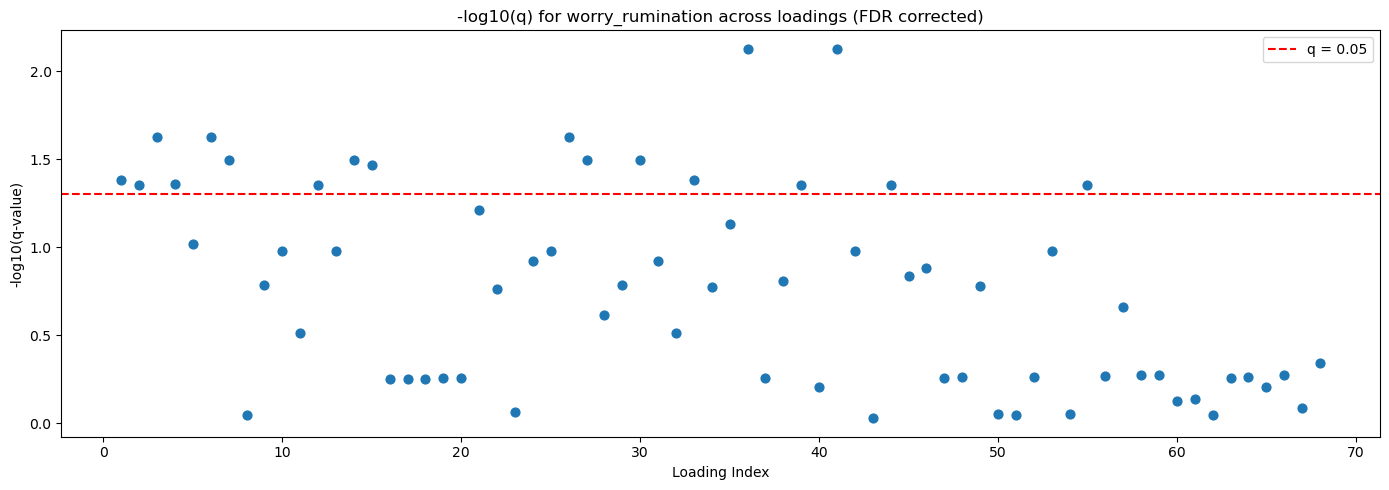

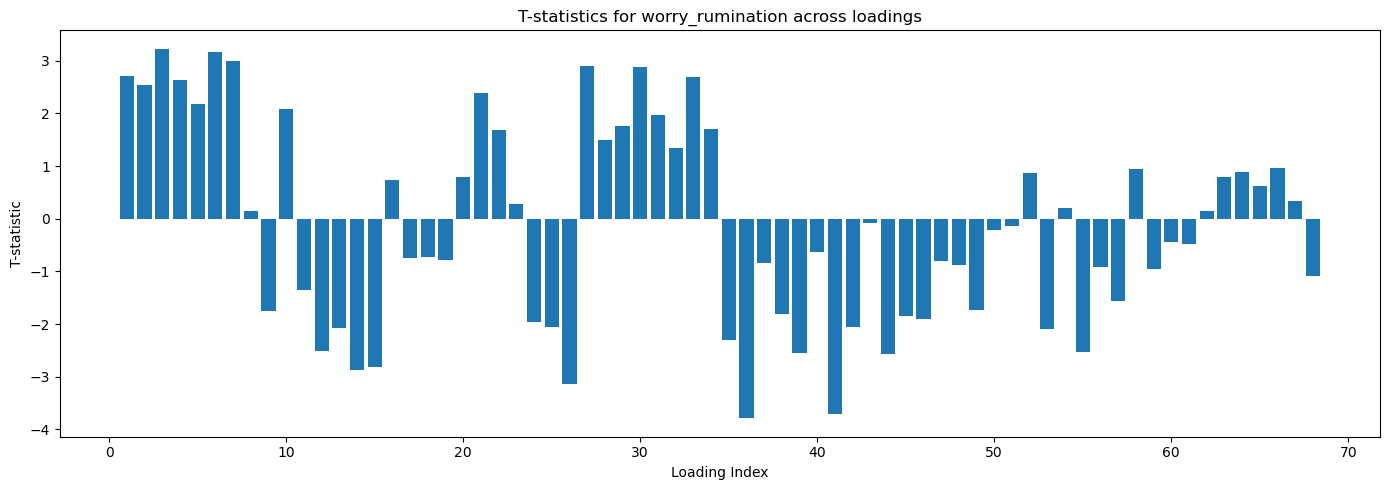

    Loading   p_worry   q_worry   T_worry    p_mood    q_mood    T_mood  \
0         1  0.006910  0.041626  2.703499  0.504516  0.897409 -0.667502   
1         2  0.011168  0.044412  2.539376  0.002847  0.096810 -2.986863   
2         3  0.001267  0.023617  3.227137  0.004818  0.109210 -2.821603   
3         4  0.008370  0.043783  2.638961  0.027333  0.309778 -2.208086   
5         6  0.001600  0.023617  3.159607  0.074354  0.474947 -1.785213   
6         7  0.002817  0.031805  2.990192  0.190924  0.590130 -1.308222   
11       12  0.011756  0.044412 -2.521326  0.444599  0.839798  0.764577   
13       14  0.004210  0.031805 -2.864784  0.605991  0.930291  0.515874   
14       15  0.004980  0.033865 -2.810935  0.240027  0.680076  1.175214   
25       26  0.001737  0.023617 -3.135508  0.872991  0.957474  0.159878   
26       27  0.003805  0.031805  2.896765  0.002679  0.096810 -3.005534   
29       30  0.003884  0.031805  2.890287  0.743742  0.949427 -0.326940   
32       33  0.007346  0.

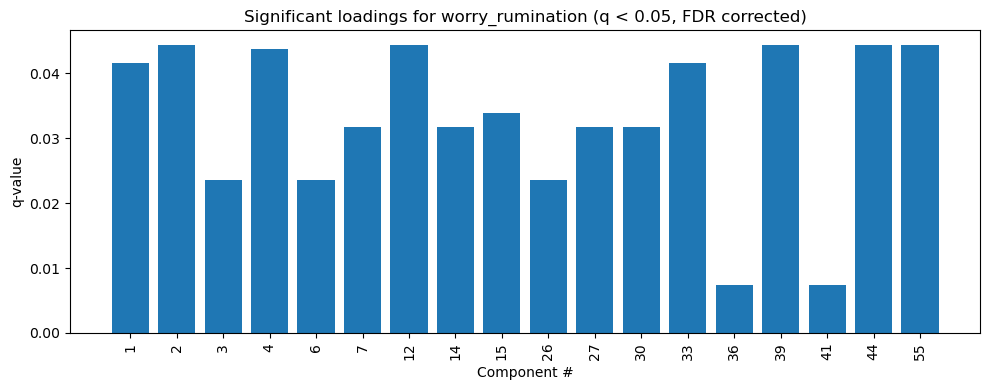

    Loading   p_worry   q_worry   T_worry    p_mood    q_mood    T_mood  \
35       36  0.000155  0.007437 -3.788998  0.741015  0.949427 -0.330549   
40       41  0.000219  0.007437 -3.702031  0.615634  0.930291  0.502114   

    p_social  q_social  T_social  
35  0.946188  0.960311 -0.067501  
40  0.054749  0.202713 -1.921807  


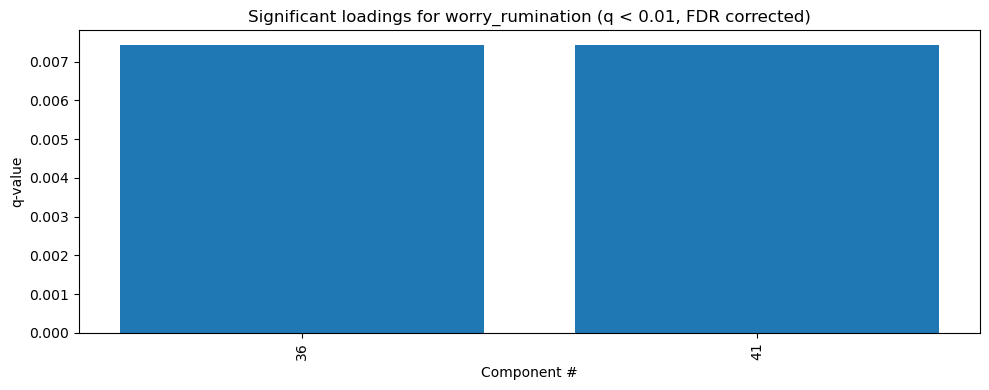

In [20]:
#plot 1st plot for factor: worry_rumination FDR corrected
#check labels variable
display(clean_labels) #check as a sanity check

import matplotlib.pyplot as plt
import numpy as np

# Ensure no zero q-values (avoid -log10(0) crash)
results["q_worry"] = results["q_worry"].replace(0, 1e-300)

# --- LOG PLOT (worry, q-values) ---
plt.figure(figsize=(14, 5))
plt.scatter(results["Loading"], -np.log10(results["q_worry"]), s=40)
plt.axhline(-np.log10(0.05), color="red", linestyle="--", label="q = 0.05")
plt.xlabel("Loading Index")
plt.ylabel("-log10(q-value)")
plt.title("-log10(q) for worry_rumination across loadings (FDR corrected)")
plt.legend()
plt.tight_layout()
plt.show()

# --- T-STAT PLOT (worry) ---
plt.figure(figsize=(14, 5))
plt.bar(results["Loading"], results["T_worry"])
plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for worry_rumination across loadings")
plt.tight_layout()
plt.show()


# --- SIGNIFICANT LOADINGS q < 0.05 ---
sig = results[results["q_worry"] < 0.05]
print(sig)

sig_labels = sig["Loading"].astype(int).astype(str).tolist()

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["q_worry"])
plt.xticks(rotation=90)
plt.title("Significant loadings for worry_rumination (q < 0.05, FDR corrected)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()

# --- SIGNIFICANT LOADINGS q < 0.01 ---
sig = results[results["q_worry"] < 0.01]
print(sig)

sig_labels = sig["Loading"].astype(int).astype(str).tolist()

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["q_worry"])
plt.xticks(rotation=90)
plt.title("Significant loadings for worry_rumination (q < 0.01, FDR corrected)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()

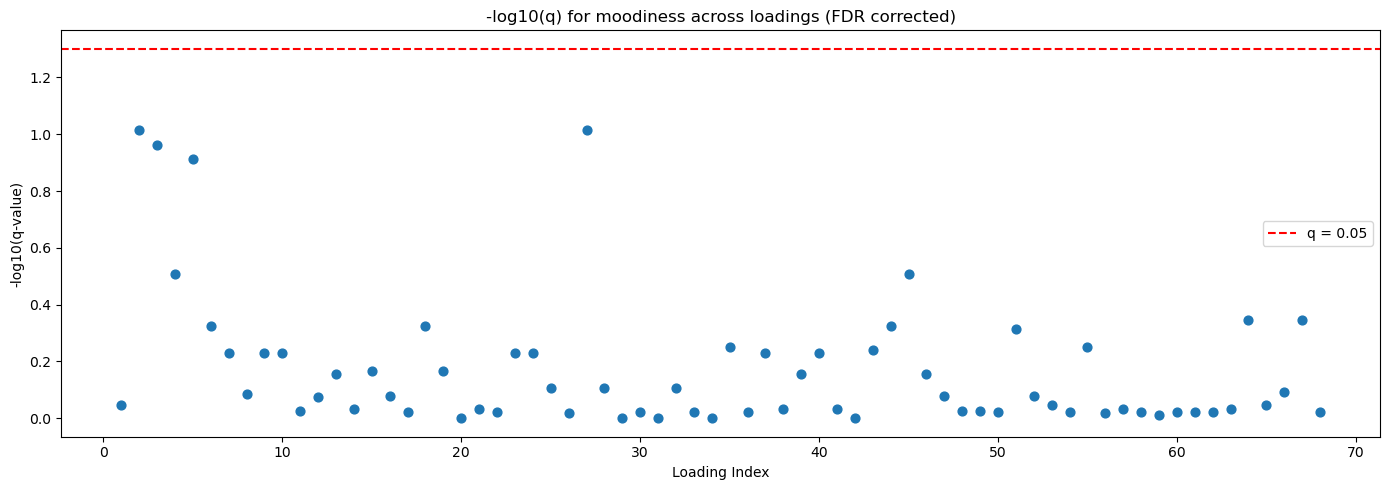

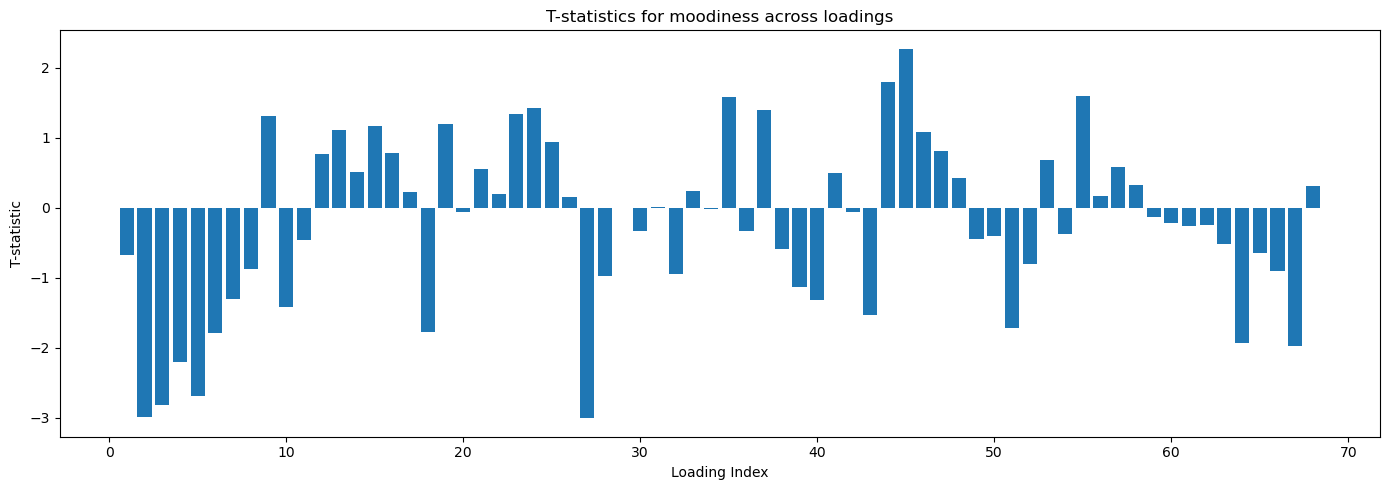

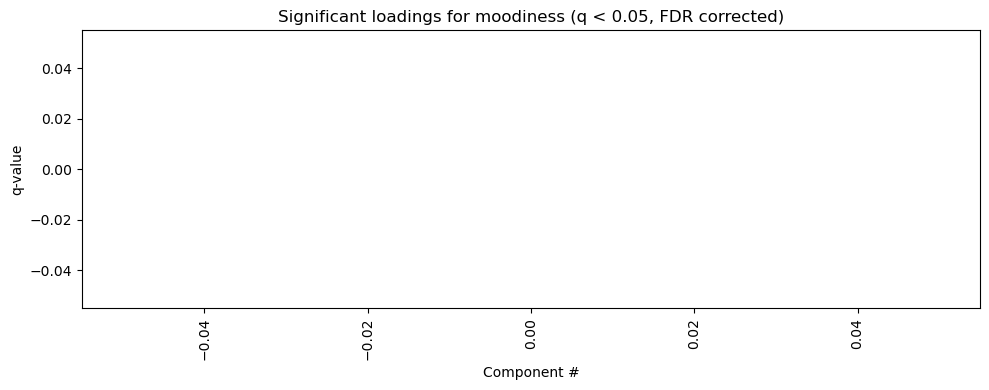

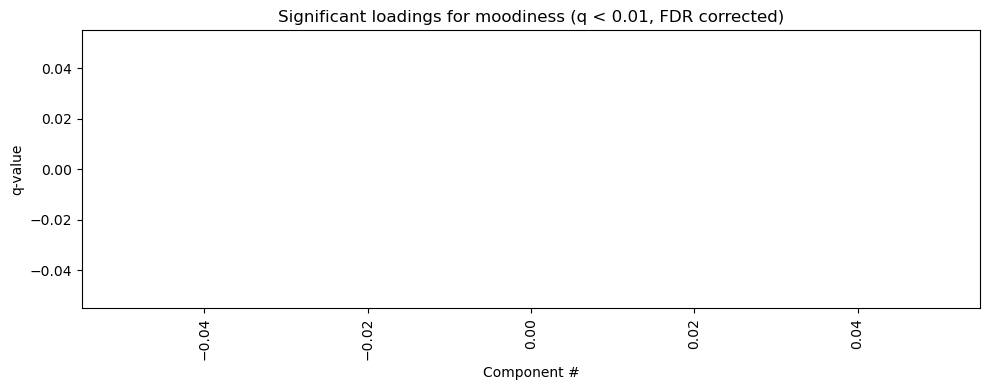

In [21]:
#plot 2nd plot with moodiness 

import matplotlib.pyplot as plt
import numpy as np

# Ensure no zero q-values (avoid -log10(0) crash)
results["q_mood"] = results["q_mood"].replace(0, 1e-300)

# --- LOG PLOT (moodiness, q-values) ---
plt.figure(figsize=(14, 5))
plt.scatter(results["Loading"], -np.log10(results["q_mood"]), s=40)
plt.axhline(-np.log10(0.05), color="red", linestyle="--", label="q = 0.05")
plt.xlabel("Loading Index")
plt.ylabel("-log10(q-value)")
plt.title("-log10(q) for moodiness across loadings (FDR corrected)")
plt.legend()
plt.tight_layout()
plt.show()

# --- T-STAT PLOT (moodiness) ---
plt.figure(figsize=(14, 5))
plt.bar(results["Loading"], results["T_mood"])
plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for moodiness across loadings")
plt.tight_layout()
plt.show()

# --- Significant q < 0.05 ---
sig = results[results["q_mood"] < 0.05]
sig_labels = sig["Loading"].astype(int).astype(str).tolist()

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["q_mood"])
plt.xticks(rotation=90)
plt.title("Significant loadings for moodiness (q < 0.05, FDR corrected)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()

# --- Significant q < 0.01 ---
sig = results[results["q_mood"] < 0.01]
sig_labels = sig["Loading"].astype(int).astype(str).tolist()

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["q_mood"])
plt.xticks(rotation=90)
plt.title("Significant loadings for moodiness (q < 0.01, FDR corrected)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()


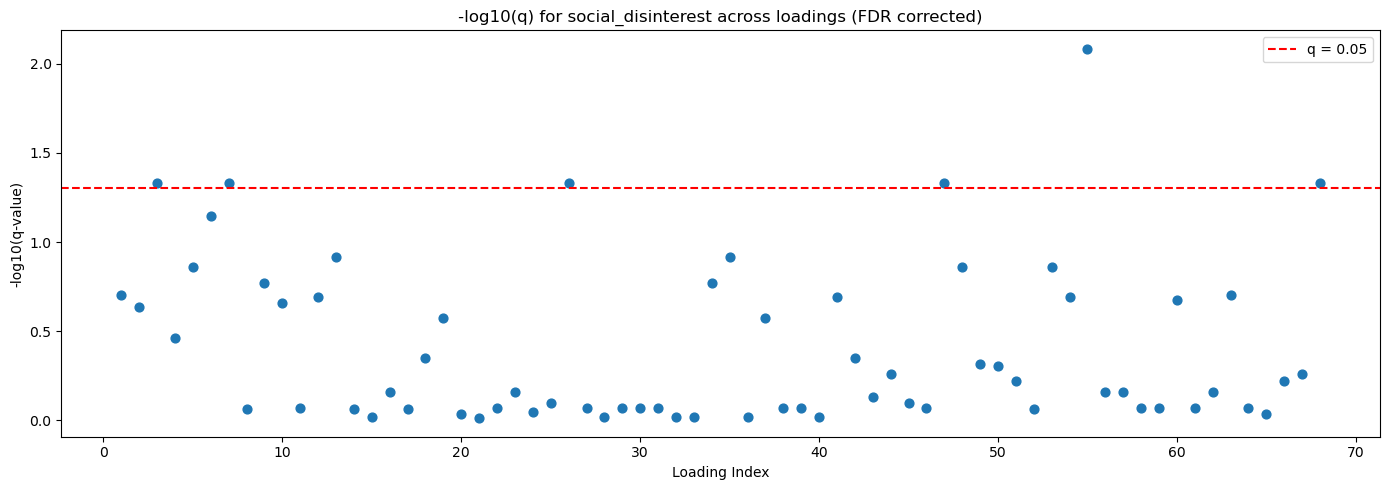

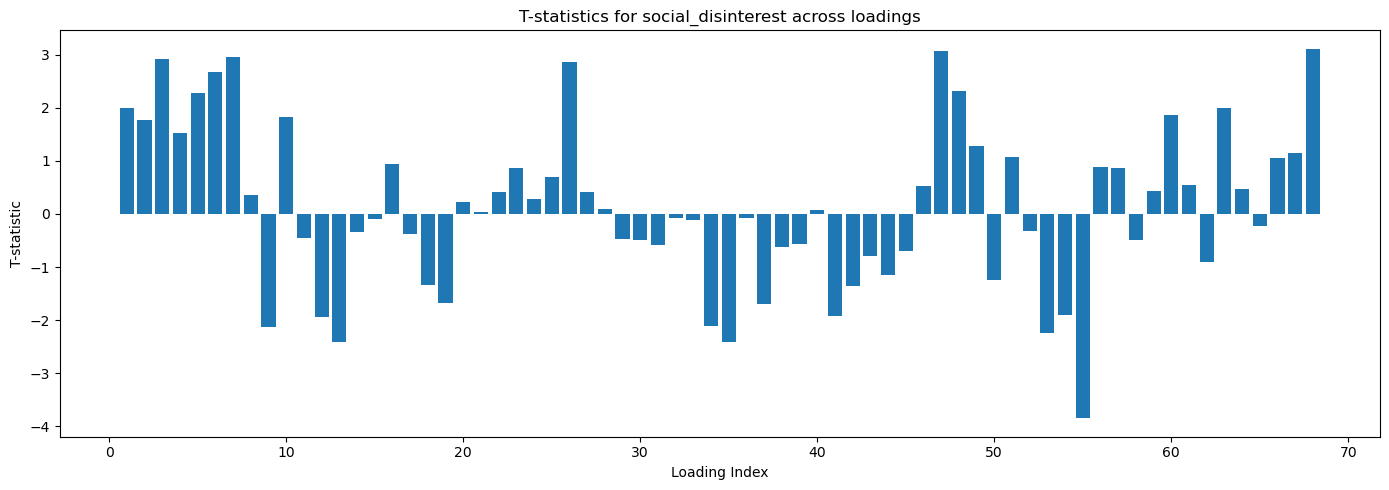

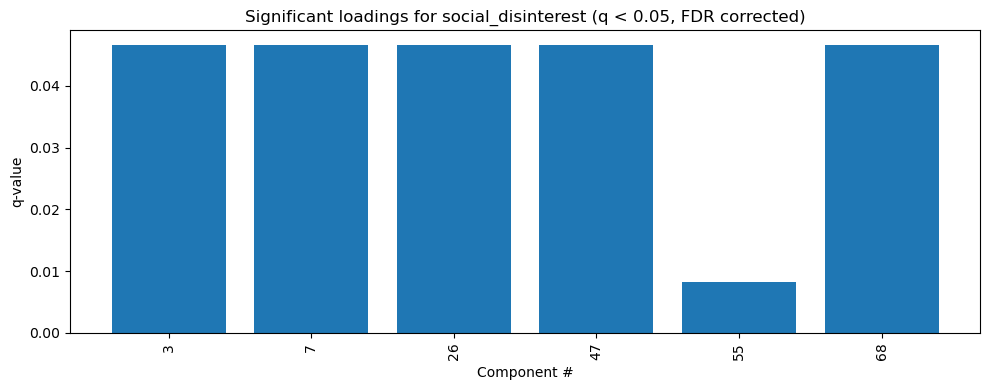

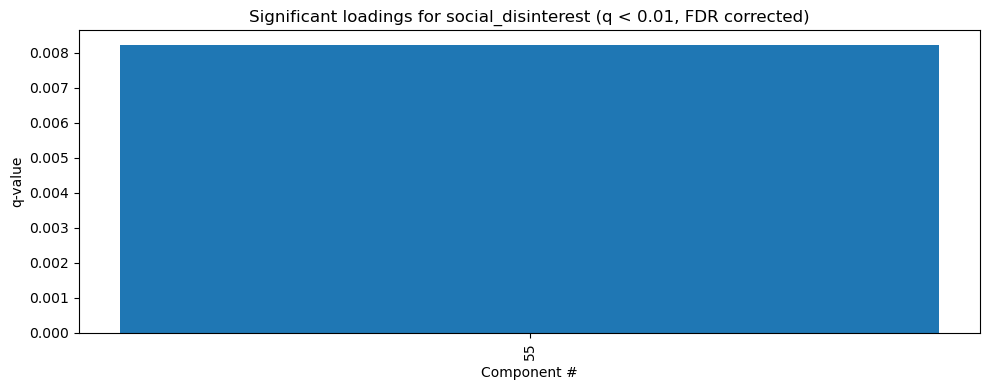

In [22]:
import matplotlib.pyplot as plt
import numpy as np

# Ensure no zero q-values (avoid -log10(0) crash)
results["q_social"] = results["q_social"].replace(0, 1e-300)

# --- LOG PLOT (social_disinterest, q-values) ---
plt.figure(figsize=(14, 5))
plt.scatter(results["Loading"], -np.log10(results["q_social"]), s=40)
plt.axhline(-np.log10(0.05), color="red", linestyle="--", label="q = 0.05")
plt.xlabel("Loading Index")
plt.ylabel("-log10(q-value)")
plt.title("-log10(q) for social_disinterest across loadings (FDR corrected)")
plt.legend()
plt.tight_layout()
plt.show()

# --- T-STAT PLOT (social_disinterest) ---
plt.figure(figsize=(14, 5))
plt.bar(results["Loading"], results["T_social"])
plt.xlabel("Loading Index")
plt.ylabel("T-statistic")
plt.title("T-statistics for social_disinterest across loadings")
plt.tight_layout()
plt.show()

# --- Significant q < 0.05 ---
sig = results[results["q_social"] < 0.05]
sig_labels = sig["Loading"].astype(int).astype(str).tolist()

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["q_social"])
plt.xticks(rotation=90)
plt.title("Significant loadings for social_disinterest (q < 0.05, FDR corrected)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()

# --- Significant q < 0.01 ---
sig = results[results["q_social"] < 0.01]
sig_labels = sig["Loading"].astype(int).astype(str).tolist()

plt.figure(figsize=(10, 4))
plt.bar(sig_labels, sig["q_social"])
plt.xticks(rotation=90)
plt.title("Significant loadings for social_disinterest (q < 0.01, FDR corrected)")
plt.xlabel("Component #")
plt.ylabel("q-value")
plt.tight_layout()
plt.show()


In [23]:
# run CoM matrix regressions, generate p and q values
#nothing survives FDR correction

import pandas as pd
import statsmodels.api as sm
from statsmodels.formula.api import ols
import numpy as np
from statsmodels.stats.multitest import multipletests

results = []

# Loop over upper triangle only (j > i)
for i in range(68):
    for j in range(i + 1, 68):

        # Extract subject-level CoM values for this edge  
        df["CoM_val"] = all_matrices_dep[i, j, :]

        # Regression formula with all 3 factors
        formula = (
            "CoM_val ~ age + C(sex_coded) + C(Location_ID) + "
            "worry_rumination + moodiness + social_disinterest"
        )

        # Fit model
        model = ols(formula, data=df).fit()
        anova = sm.stats.anova_lm(model, typ=2)

        # Extract p-values (from ANOVA)
        p_worry = float(anova.loc["worry_rumination", "PR(>F)"])
        p_mood = float(anova.loc["moodiness", "PR(>F)"])
        p_social = float(anova.loc["social_disinterest", "PR(>F)"])

        # Extract T-statistics (from model coefficients)
        T_worry = float(model.tvalues["worry_rumination"])
        T_mood = float(model.tvalues["moodiness"])
        T_social = float(model.tvalues["social_disinterest"])

        # Store results
        results.append([
            i+1, j+1,
            p_worry, T_worry,
            p_mood, T_mood,
            p_social, T_social
        ])

# Convert to DataFrame
results_df = pd.DataFrame(
    results,
    columns=[
        "Row", "Col",
        "p_worry", "T_worry",
        "p_mood", "T_mood",
        "p_social", "T_social"
    ]
)

# --- FDR correction (Benjamini–Hochberg) ---
results_df["q_worry"] = multipletests(results_df["p_worry"], method='fdr_bh')[1]
results_df["q_mood"] = multipletests(results_df["p_mood"], method='fdr_bh')[1]
results_df["q_social"] = multipletests(results_df["p_social"], method='fdr_bh')[1]

print(results_df)


      Row  Col   p_worry   T_worry    p_mood    T_mood  p_social  T_social  \
0       1    2  0.650673  0.452885  0.321829  0.990913  0.577806 -0.556669   
1       1    3  0.611171  0.508469  0.869895  0.163809  0.704940 -0.378706   
2       1    4  0.066007 -1.839223  0.373539  0.890032  0.283655 -1.072386   
3       1    5  0.236525 -1.184017  0.364372 -0.907240  0.067653 -1.828143   
4       1    6  0.603169  0.519918  0.022579  2.281965  0.124506 -1.536673   
...   ...  ...       ...       ...       ...       ...       ...       ...   
2273   65   67  0.946314 -0.067343  0.183638  1.330023  0.436356 -0.778493   
2274   65   68  0.388854 -0.861856  0.572996  0.563723  0.300803 -1.034938   
2275   66   67  0.672310  0.423032  0.019610  2.335306  0.996844 -0.003956   
2276   66   68  0.600505  0.523745  0.943957 -0.070305  0.966380 -0.042154   
2277   67   68  0.614639 -0.503529  0.509500  0.659716  0.543710  0.607300   

       q_worry    q_mood  q_social  
0     0.977456  0.884491  

In [24]:
import numpy as np

def build_p_matrix(results_df, p_col, n=68, alpha=0.05):
    """
    Build a p-value matrix for CoM edges.

    Lower triangle: all p-values
    Upper triangle: only significant p-values (p < alpha)
    """

    results_df = results_df.copy()

    # Initialize matrix
    p_matrix = np.full((n, n), np.nan)

    # Fill lower triangle with all p-values
    for _, row in results_df.iterrows():
        i = int(row["Row"]) - 1
        j = int(row["Col"]) - 1
        p = row[p_col]

        if j < i:   # lower triangle
            p_matrix[i, j] = p

    # Fill upper triangle with significant p-values only
    for _, row in results_df.iterrows():
        i = int(row["Row"]) - 1
        j = int(row["Col"]) - 1
        p = row[p_col]

        if j > i:   # upper triangle
            p_matrix[i, j] = p if p < alpha else np.nan

    # Diagonal stays empty
    np.fill_diagonal(p_matrix, np.nan)

    return p_matrix


In [25]:
def plot_p_matrix(p_matrix, title, clean_labels):
    plt.figure(figsize=(14, 12))
    sns.heatmap(
        p_matrix,
        cmap="viridis_r",
        vmin=0,
        vmax=0.05,      # p < .05 threshold visualization
        mask=np.isnan(p_matrix)
    )

    plt.title(title, fontsize=16)

    plt.xticks(
        ticks=np.arange(68) + 0.5,
        labels=clean_labels,
        rotation=90,
        fontsize=8
    )
    plt.yticks(
        ticks=np.arange(68) + 0.5,
        labels=clean_labels,
        rotation=0,
        fontsize=8
    )

    plt.xlabel("Components (1–68)", fontsize=12)
    plt.ylabel("Components (1–68)", fontsize=12)
    plt.tight_layout()
    plt.show()


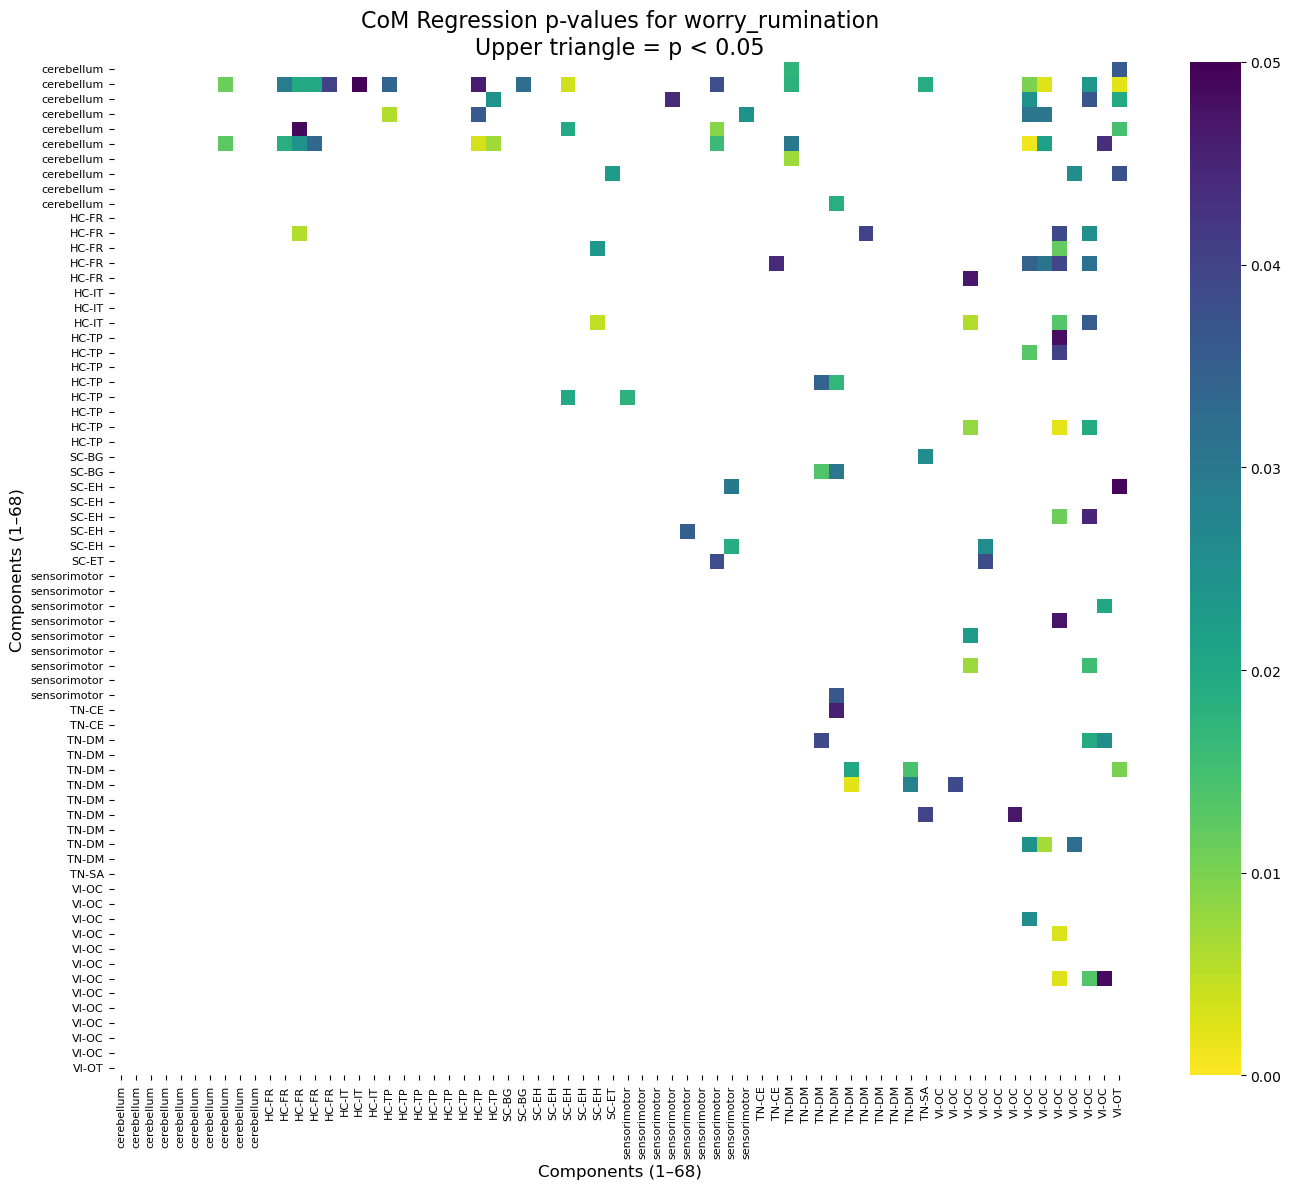

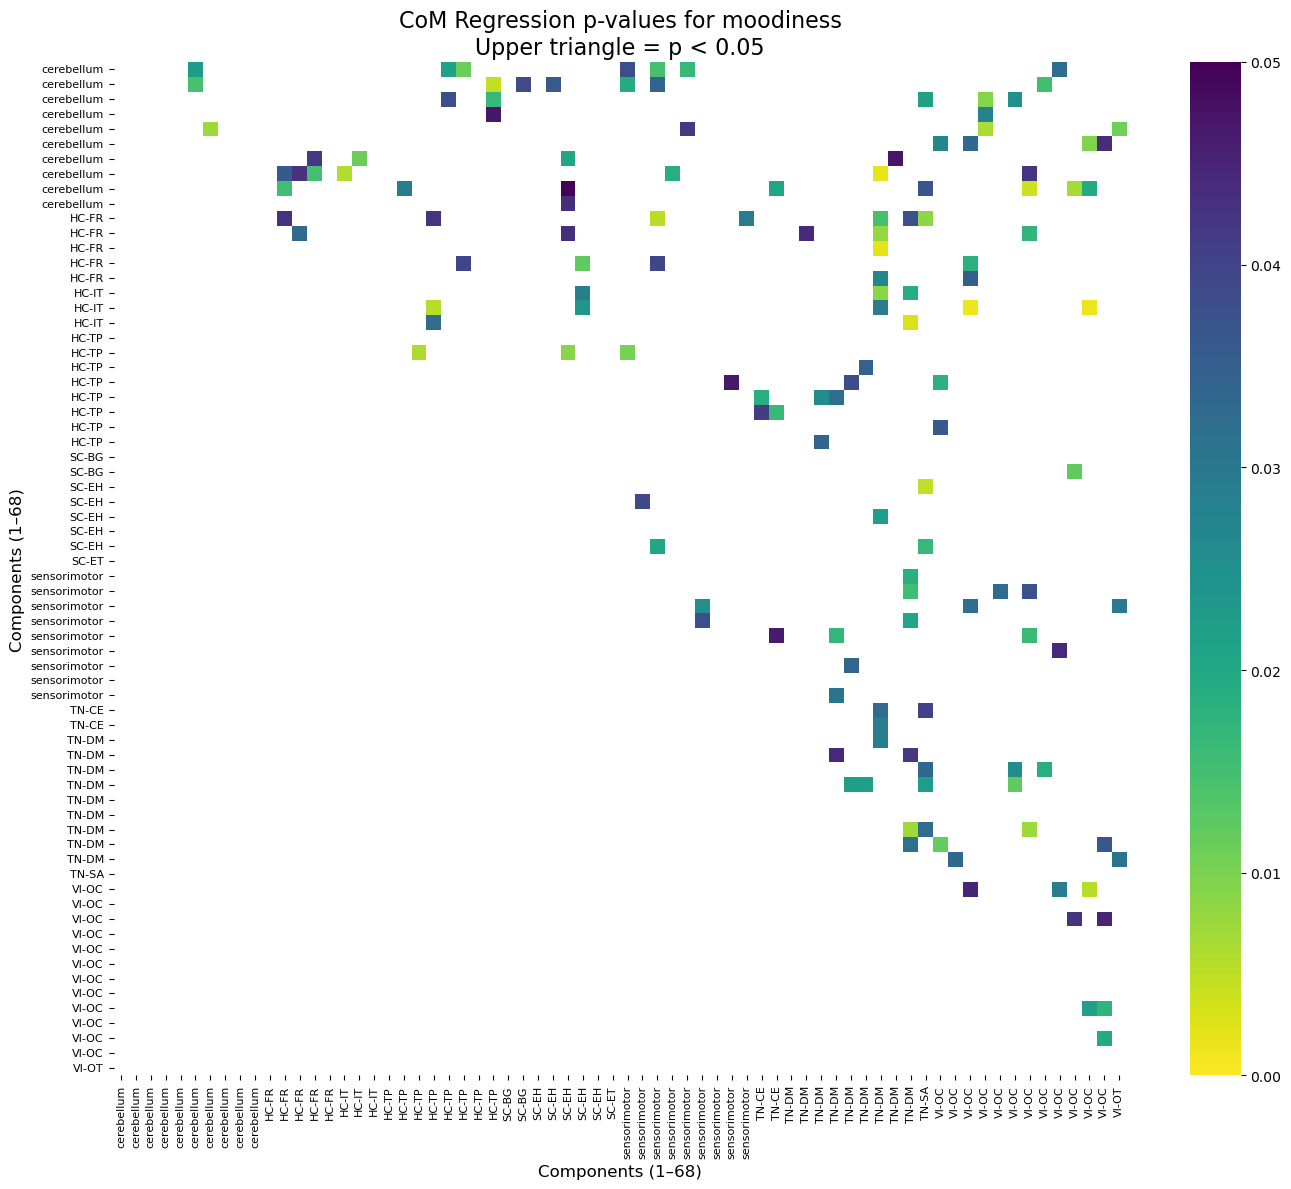

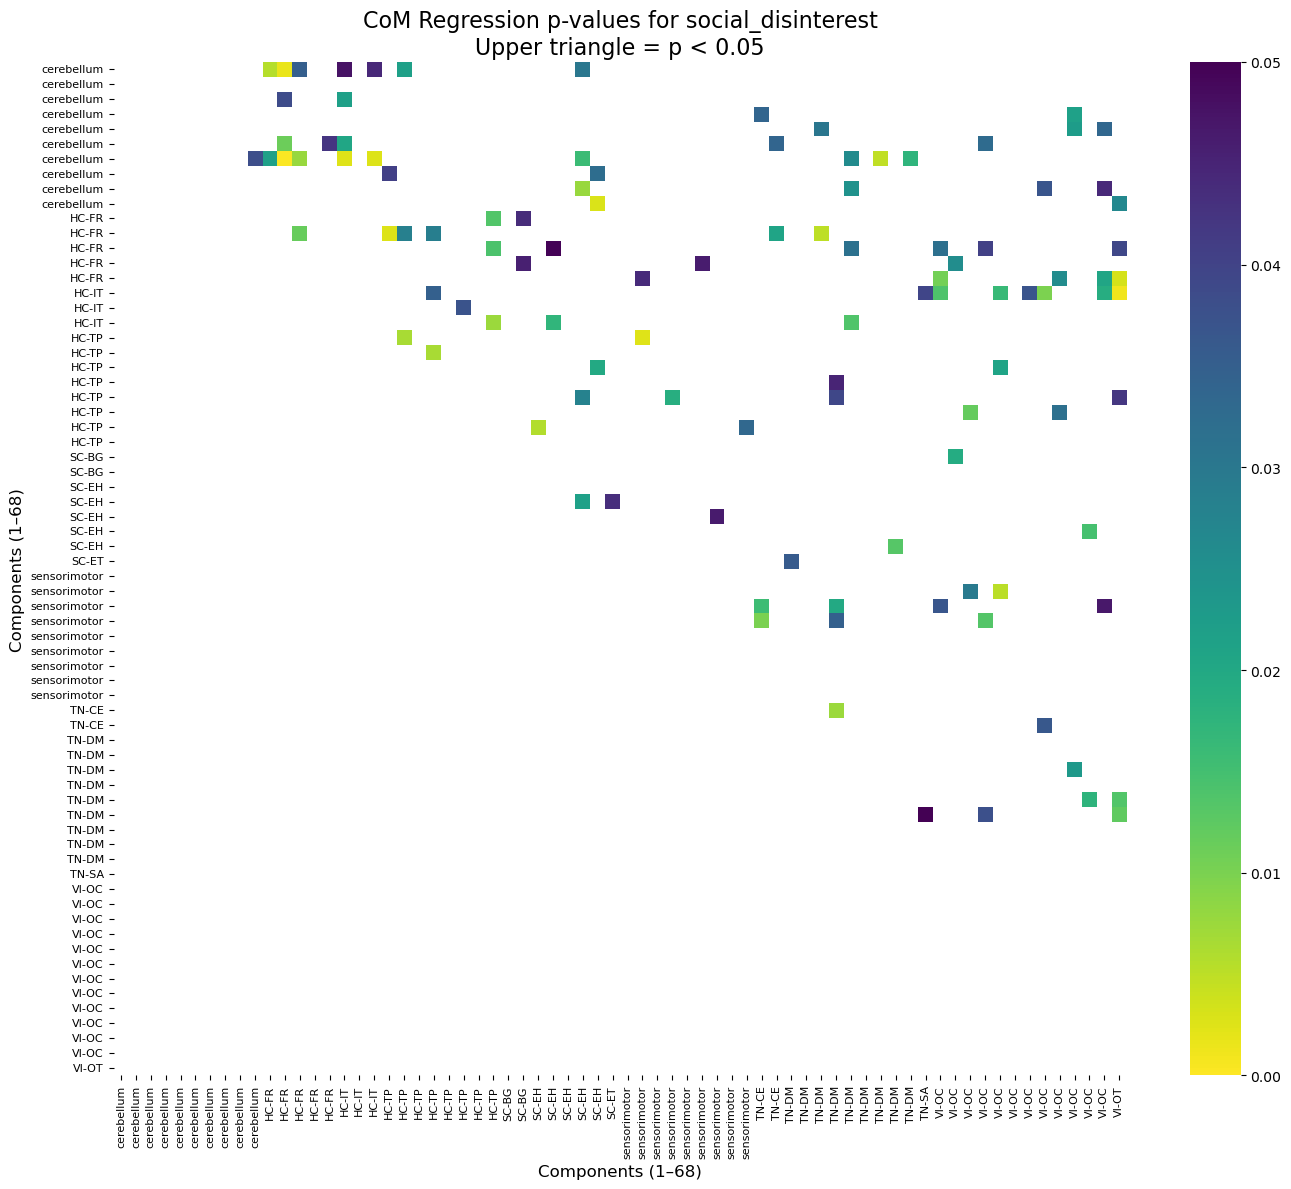

In [26]:
# heatmaps for worry, moodiness, and social disinterest (p-values)

# worry
p_matrix_worry = build_p_matrix(results_df, "p_worry")

plot_p_matrix(
    p_matrix_worry,
    "CoM Regression p-values for worry_rumination\nUpper triangle = p < 0.05",
    clean_labels
)

# moodiness
p_matrix_mood = build_p_matrix(results_df, "p_mood")

plot_p_matrix(
    p_matrix_mood,
    "CoM Regression p-values for moodiness\nUpper triangle = p < 0.05",
    clean_labels
)

# social disinterest
p_matrix_social = build_p_matrix(results_df, "p_social")

plot_p_matrix(
    p_matrix_social,
    "CoM Regression p-values for social_disinterest\nUpper triangle = p < 0.05",
    clean_labels
)
